In [22]:
import yfinance as yf
import pandas as pd
import datetime as dt

from scipy.cluster.hierarchy import average

import hist_volatility
from riskfree_and_spot import *
from hist_volatility import *
from blackscholes import *
from binomial import *
from imp_volatility import *
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

In [2]:

option_style = "american" #european / american
valuation_date = "2026-08-04" #YYYY-MM-DD
ticker = "MSFT"
expiration = "2026-08-05"
strike = 487.5
option_type = "Call" # call / put
volatility_method = "historical" #historical / (implied /not yet implemented/)
hist_vol_lookback = 0.01 #in years

#BINOMIAL
n_for_binomial = 1500 #t0 + n steps



In [3]:
spot_price = get_spot_price_data(ticker=ticker, valuation_date=valuation_date)
t_t_m = option_tenor_calc(val_date=valuation_date, exp_date=expiration)
risk_free_rate = get_risk_free_rate(val_date=valuation_date, exp_date=expiration)
vol = get_volatility(ticker=ticker, val_date=valuation_date, lookback=hist_vol_lookback)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
ticker_obj = yf.Ticker(ticker)

exps = ticker_obj.options

rf_for_exp = {
    date: {
        "tenor": option_tenor_calc(val_date=valuation_date, exp_date=date),
        "rf_rate": get_risk_free_rate(val_date=valuation_date, exp_date=date),
    }
    for date in exps
}

hist_vol = get_volatility(ticker = ticker, val_date=valuation_date, lookback=hist_vol_lookback)

spot_for_iv = get_spot_price_data(ticker=ticker, valuation_date=valuation_date)


all_data = []

for date in exps:
    option_chain = ticker_obj.option_chain(date)
    if option_type.lower() =="call":
        type_chain = option_chain.calls
    elif option_type.lower() =="put":
        type_chain = option_chain.puts
    else:
        raise ValueError("option_style must be either 'call' or 'put'")
    type_chain["expirtaion"] = date
    type_chain["tenor"] = rf_for_exp[date]["tenor"]
    type_chain["rf_rate"] = rf_for_exp[date]["rf_rate"]

    all_data.append(type_chain)

all_data = pd.concat(all_data, ignore_index = True)
all_data


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expirtaion,tenor,rf_rate
0,MSFT260805C00310000,2026-08-05 19:13:46+00:00,310.0,180.40,176.40,179.35,-6.070007,-3.255219,8.0,7,3.964844,True,REGULAR,USD,2026-08-05,0.002740,0.037800
1,MSFT260805C00320000,2026-08-05 19:08:00+00:00,320.0,169.87,166.40,169.35,-7.260010,-4.098690,6.0,5,3.716798,True,REGULAR,USD,2026-08-05,0.002740,0.037800
2,MSFT260805C00322500,2026-08-05 19:04:49+00:00,322.5,167.30,163.95,166.85,-7.129990,-4.087594,10.0,4,3.685548,True,REGULAR,USD,2026-08-05,0.002740,0.037800
3,MSFT260805C00325000,2026-08-05 19:05:10+00:00,325.0,164.83,161.05,164.35,-7.229996,-4.202020,11.0,19,3.339845,True,REGULAR,USD,2026-08-05,0.002740,0.037800
4,MSFT260805C00327500,2026-08-05 19:10:54+00:00,327.5,162.51,159.15,161.85,-6.760010,-3.993625,11.0,15,3.673829,True,REGULAR,USD,2026-08-05,0.002740,0.037800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,MSFT281215C00710000,2026-08-05 16:43:52+00:00,710.0,54.10,51.75,54.30,0.609997,1.140394,52.0,319,0.385245,False,REGULAR,USD,2028-12-15,2.367123,0.042159
1697,MSFT281215C00715000,2026-08-05 18:54:20+00:00,715.0,52.00,51.00,54.40,1.950001,3.896105,19.0,0,0.388693,False,REGULAR,USD,2028-12-15,2.367123,0.042159
1698,MSFT281215C00720000,2026-08-05 16:43:45+00:00,720.0,52.20,50.15,52.30,0.650002,1.260915,19.0,904,0.384284,False,REGULAR,USD,2028-12-15,2.367123,0.042159
1699,MSFT281215C00725000,2026-08-05 19:22:09+00:00,725.0,51.87,49.15,52.75,0.889999,1.745781,135.0,1803,0.388907,False,REGULAR,USD,2028-12-15,2.367123,0.042159


In [10]:
s = spot_for_iv
vol = vol
calc_iv_list = []

for i, row in all_data.iterrows():
    k = row["strike"]
    t = row["tenor"]
    r = row["rf_rate"]
    target = (row["bid"] + row["ask"]) / 2
    implied_vol = find_vol_bs(target_value=target, S=s, K=k, T=t, r=r, vol=vol, opt_type=option_type)
    calc_iv_list.append(implied_vol)

all_data["calc_imp_vol"] = calc_iv_list



In [17]:
iv_fig_data = all_data[
    (all_data["bid"] > 0) &
    (all_data["ask"] > 0) &
    (all_data["openInterest"] > 0) &
    (all_data["strike"] > spot_for_iv * 0.8) &
    (all_data["strike"] < spot_for_iv * 1.2)
]

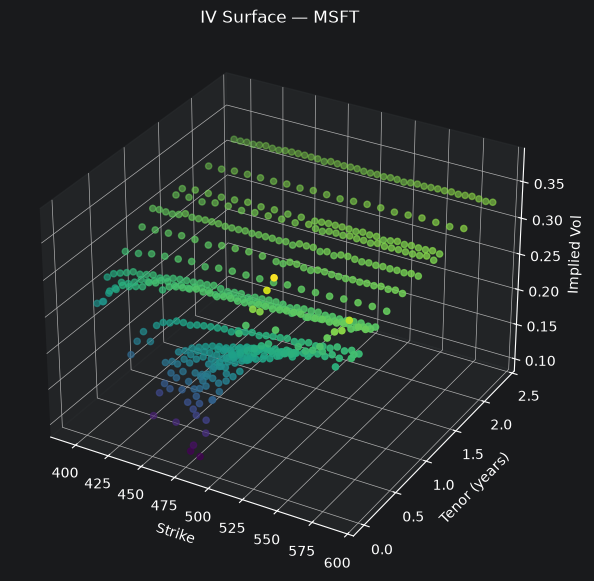

In [20]:


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(iv_fig_data["strike"], iv_fig_data["tenor"], iv_fig_data["calc_imp_vol"], c=iv_fig_data["calc_imp_vol"], cmap="viridis")
ax.set_xlabel("Strike")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
ax.set_title(f"IV Surface — {ticker}")
plt.show()

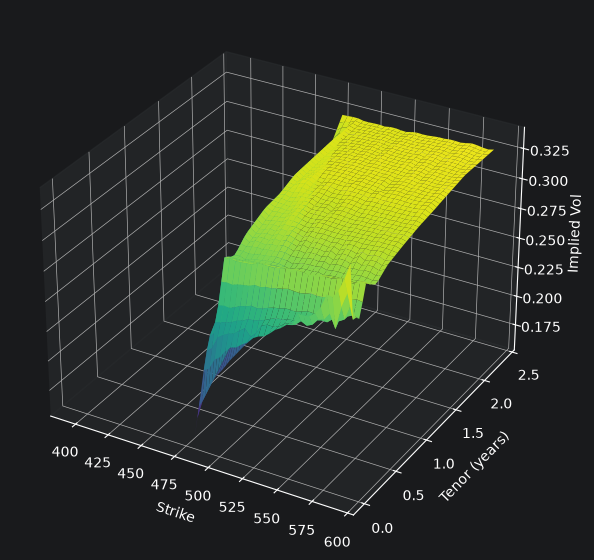

In [25]:


strikes = np.linspace(iv_fig_data["strike"].min(), iv_fig_data["strike"].max(), 50)
tenors = np.linspace(iv_fig_data["tenor"].min(), iv_fig_data["tenor"].max(), 50)
grid_x, grid_y = np.meshgrid(strikes, tenors)

grid_z = griddata(
    (iv_fig_data["strike"], iv_fig_data["tenor"]),
    iv_fig_data["calc_imp_vol"],
    (grid_x, grid_y),
    method="linear"
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_x, grid_y, grid_z, cmap="viridis")
ax.set_xlabel("Strike")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
plt.show()